Code for Experiment 4
----------------------

This notebook contains the python code used to analyze the data collected during Experiment 4 of the paper "Building Compressed Causal Models of the World." It requires that R also be installed on your computer in order to run mixed ANOVAs.

In [1]:
#Import all required packages.

import os
os.environ['R_HOME']='/Library/Frameworks/R.framework/Resources' #The home for R on your computer may differ. 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import pandas2ri, StrVector
from rpy2.robjects.conversion import localconverter
from scipy.stats import chi2_contingency

The following block of code imports and cleans the data in the file 'study_4_data.csv'.

In [2]:
data = pd.read_csv('study_4_data.csv')
data=data.drop(labels=0,axis=0) 
data=data.drop(labels=1,axis=0)
data = data[data.Status != 'Survey Preview']
data = data.reset_index()

exclusions = []
for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and (data.P_MD_2C_A[i] == 'No' or data.P_MD_2C_B[i] == 'No' or data.P_MD_2C_C[i] == 'Yes' or\
                                              data.P_MD_2C_D[i] == 'Yes' or data.P_POA_2C_1[i] == 'False' or\
                                              data.P_POA_2C_2[i] == 'True' or data.P_POA_2C_3[i] == 'False' or\
                                              data.P_POA_2C_4[i] == 'True' or data.T_MD_2C_A[i] == 'No' or data.T_MD_2C_B[i] == 'No' or\
                                              data.T_MD_2C_C[i] == 'Yes' or data.T_MD_2C_D[i] == 'Yes' or data.T_POA_2C_1[i] == 'False' or\
                                              data.T_POA_2C_2[i] == 'True' or data.T_POA_2C_3[i] == 'False' or\
                                              data.T_POA_2C_4[i] == 'True'):
        exclusions = np.append(exclusions,[i])
        
    if data.DifferenceMatters[i] == 'Yes' and (data.P_MD_2C_A[i] == 'No' or data.P_MD_2C_B[i] == 'Yes' or\
                                              data.P_MD_2C_C[i] == 'Yes' or data.P_MD_2C_D[i] == 'Yes' or data.P_POA_2C_1[i] == 'True' or data.P_POA_2C_2[i] == 'False' or data.P_POA_2C_3[i] == 'False' or\
                                              data.P_POA_2C_4[i] == 'True' or data.T_MD_2C_A[i] == 'No' or data.T_MD_2C_B[i] == 'Yes' or\
                                              data.T_MD_2C_C[i] == 'Yes' or data.T_MD_2C_D[i] == 'Yes' or data.T_POA_2C_1[i] == 'True' or data.T_POA_2[i] == 'False' or data.T_POA_2C_3[i] == 'False' or\
                                              data.T_POA_2C_4[i] == 'True'):
        exclusions = np.append(exclusions,[i])
        
    if data.DifferenceMatters[i] == 'No' and (data.T_MD_A[i] == 'Yes' and data.T_MD_B[i] == 'Yes' and data.T_MD_C[i] == 'No' and\
                                              data.T_MD_D[i] == 'No') and (data.T_MD_2C_A[i] == 'Yes' or data.T_MD_2C_A[i] == 'No'):
        exclusions = np.append(exclusions,[i])
        
data=data.drop(labels=exclusions,axis=0)





for i in range(0,4):
    s = str(i)
    data = data[data.P_CE_CompBad_1 != s]

for i in range(0,4):
    s = str(i)
    data = data[data.P_CE_HighBad_1 != s]

for i in range(0,4):
    s = str(i)
    data = data[data.P_CE_LowBad_1 != s]      

for i in range(0,4):
    s = str(i)
    data = data[data.T_CE_CompBad_1 != s]

for i in range(0,4):
    s = str(i)
    data = data[data.T_CE_HighBad_1 != s]

for i in range(0,4):
    s = str(i)
    data = data[data.T_CE_LowBad_1 != s]


    
data = data.reset_index()

The following block constructs arrays whose values denote:

1. The vignette shown to each participant (vignette)
2. The information loss inherent in choosing a compressed over a non-compressed causal representation in the vignette shown to each participant (loss_vals)
3. Whether the participant was shown a vignette in which compression involved coarsening a causal variable or eliding a background variable (mode).
4. Whether VOLI was zero or positive (diff_matters_
5. The participant's evaluation of the causal claim Compressed (comp_eval).
6. The participant's evaluation of the causal claim High (high_eval).
7. The participant's evaluation of the causal claim Low (low_eval).
8. The difference between the participant's evaluation of the causal claim Compressed and the causal claim High (comp_high_diff).
9. The difference between the participant's evaluation of the causal claim Compressed and the uniform avgerage of the participant's evaluation of the claims High and Low (comp_avg_diff).
10. The difference between the evaluation of the causal claim High and the uniform avgerage of the participant's evaluation of the causal claim Low (high_low_diff).

It then generates the bar chart showing the results of the experiment by VOLI category.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_75350/2767571011.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['0.0','0.5','1.0','1.5','2.0','2.5','3.0'],fontsize=30)


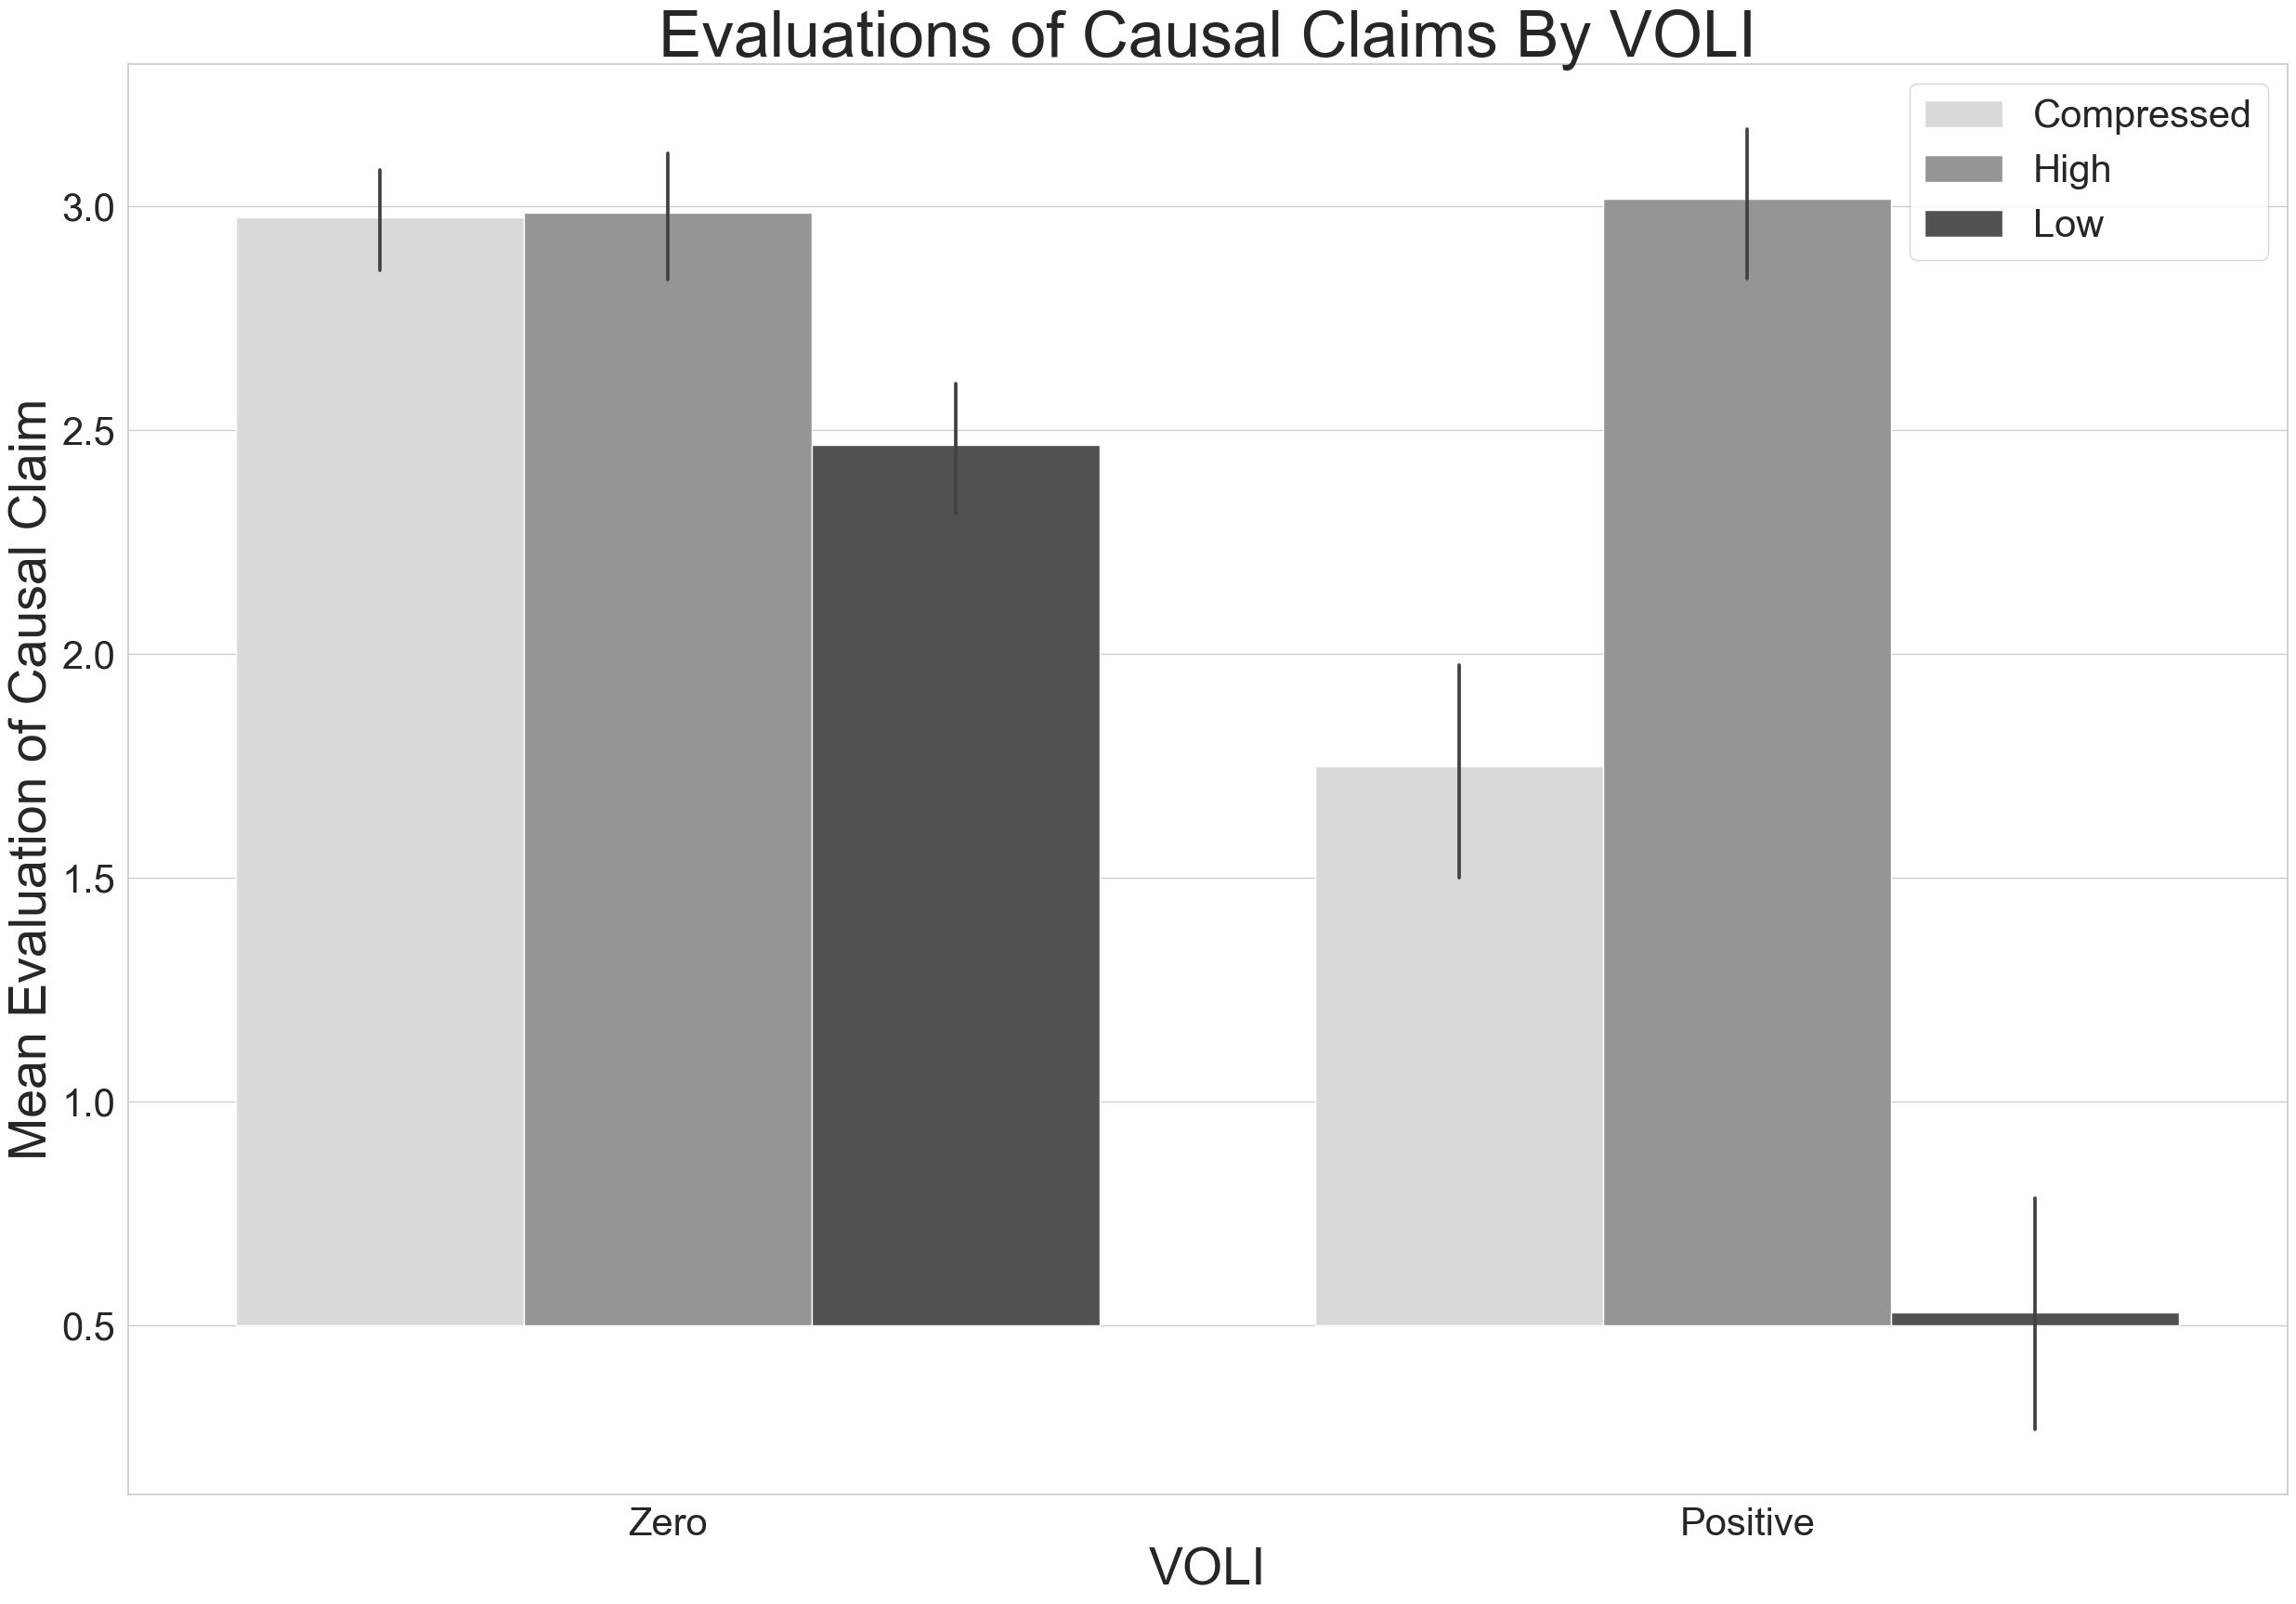

In [3]:
loss_vals = []
for i in range(0,len(data)):
    if data.Loss[i] == '1':
        loss_vals = np.append(loss_vals,[.01])
    if data.Loss[i] == '2':
        loss_vals = np.append(loss_vals,[.06])
        
mode = []
for i in range(0,len(data)):
    if data.Condition[i] == 'Prop':
        mode = np.append(mode,[-1])
    if data.Condition[i] == 'Stab':
        mode = np.append(mode,[1])
        
vignette = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        vignette = np.append(vignette,[-1])
    if data.Vignette[i] == 'Training':
        vignette = np.append(vignette,[1])
        
diff_matters = []
for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No':
        diff_matters = np.append(diff_matters,[-1])
    if data.DifferenceMatters[i] == 'Yes':
        diff_matters = np.append(diff_matters,[1])
        
comp_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
    if data.Vignette[i] == 'Training':
        comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
    
high_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
    if data.Vignette[i] == 'Training':
        high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
    
low_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
    if data.Vignette[i] == 'Training':
        low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
    
comp_high_diff = comp_eval - high_eval
comp_avg_diff = comp_eval - [.5*(high_eval[i]+low_eval[i]) for i in range(0,len(data))]
high_low_diff = high_eval - low_eval 

arr = np.hstack((diff_matters.reshape(-1,1),vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1),low_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI','Vignette', 'Mode', 'Loss', 'Compressed', 'High', 'Low'])
datamelt = df.melt('VOLI', value_vars=['Compressed','High','Low'],var_name='')
sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax=sns.barplot(x='VOLI', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('VOLI',fontsize=40)
ax.set_xticklabels(['Zero','Positive'],fontsize=30)
ax.set_yticklabels(['0.0','0.5','1.0','1.5','2.0','2.5','3.0'],fontsize=30)
ax.set_title('Evaluations of Causal Claims By VOLI',fontsize=50)
plt.legend(fontsize=30)
plt.savefig('study4_barplot')

The following block regresses the difference between the participant's evaluation of the causal claim Compressed and the causal claim High (the variable COMPRESSED-HIGH in the paper) against variables representing whether the information lost in compression has zero or positive value (VOLI), the means through which compression is achieved (Mode), the amount of information lost in compression (Loss), the vignette shown to participants (Vignette), and all interactions between these four independent variables.

In [4]:
arr = np.hstack((diff_matters.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),comp_high_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Mode', 'Loss', 'Vignette', 'Comp_High_Diff'])
mod = smf.ols(formula='Comp_High_Diff ~ VOLI + Mode + Loss + Vignette + VOLI:Mode:Loss:Vignette +\
VOLI:Mode:Loss + VOLI:Mode:Vignette + VOLI:Vignette:Loss + Loss:Mode:Vignette +\
Mode:Loss + Mode:Vignette + Mode:VOLI + Loss:Vignette + Loss:VOLI + VOLI:Vignette', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:         Comp_High_Diff   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     7.722
Date:                Mon, 01 Apr 2024   Prob (F-statistic):           4.87e-15
Time:                        23:12:35   Log-Likelihood:                -627.63
No. Observations:                 378   AIC:                             1287.
Df Residuals:                     362   BIC:                             1350.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The following block regresses the difference between the participant's evaluation of the causal claim Compressed and the causal claim High (the variable COMPRESSED-AVG(HIGH, LOW) in the paper) against variables representing whether the information lost in compression has zero or positive value (VOLI), the means through which compression is achieved (Mode), the amount of information lost in compression (Loss), the vignette shown to participants (Vignette), and all interactions between these four independent variables.

In [5]:
arr = np.hstack((diff_matters.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),comp_avg_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Mode', 'Loss', 'Vignette', 'Comp_Avg'])
mod = smf.ols(formula='Comp_Avg ~ VOLI + Mode + Loss + Vignette + VOLI:Mode:Loss:Vignette +\
VOLI:Mode:Loss + VOLI:Mode:Vignette + VOLI:Vignette:Loss + Loss:Mode:Vignette +\
Mode:Loss + Mode:Vignette + Mode:VOLI + Loss:Vignette + Loss:VOLI + VOLI:Vignette', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               Comp_Avg   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     1.797
Date:                Mon, 01 Apr 2024   Prob (F-statistic):             0.0334
Time:                        23:12:37   Log-Likelihood:                -573.38
No. Observations:                 378   AIC:                             1179.
Df Residuals:                     362   BIC:                             1242.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The following block regresses the difference between the participant's evaluation of the causal claim Compressed and the causal claim High (the variable COMPRESSED-AVG(HIGH, LOW) in the paper) against variables representing whether the information lost in compression has zero or positive value (VOLI), the means through which compression is achieved (Mode), the amount of information lost in compression (Loss), the vignette shown to participants (Vignette), and all interactions between these four independent variables.

In [6]:
arr = np.hstack((diff_matters.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),high_low_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Mode', 'Loss', 'Vignette', 'High_Low_Diff'])
mod = smf.ols(formula='High_Low_Diff ~ VOLI + Mode + Loss + Vignette + VOLI:Mode:Loss:Vignette +\
VOLI:Mode:Loss + VOLI:Mode:Vignette + VOLI:Vignette:Loss + Loss:Mode:Vignette +\
Mode:Loss + Mode:Vignette + Mode:VOLI + Loss:Vignette + Loss:VOLI + VOLI:Vignette', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          High_Low_Diff   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     12.56
Date:                Mon, 01 Apr 2024   Prob (F-statistic):           3.40e-25
Time:                        23:12:39   Log-Likelihood:                -682.05
No. Observations:                 378   AIC:                             1396.
Df Residuals:                     362   BIC:                             1459.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The following three blocks regress the participant's evaluations of Comp, High, and Low, respectively, against variables representing whether the information lost in compression has zero or positive value (VOLI), the means through which compression is achieved (Condition), the amount of information lost in compression (Loss), the vignette shown to participants (Vignette), and all interactions between these four independent variables. These regressions generate the statistics reported in the Supplemental Materials.

In [7]:
arr = np.hstack((diff_matters.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),comp_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Mode', 'Loss', 'Vignette', 'Comp_Eval'])
mod = smf.ols(formula='Comp_Eval ~ VOLI + Mode + Loss + Vignette + VOLI:Mode:Loss:Vignette +\
VOLI:Mode:Loss + VOLI:Mode:Vignette + VOLI:Vignette:Loss + Loss:Mode:Vignette +\
Mode:Loss + Mode:Vignette + Mode:VOLI + Loss:Vignette + Loss:VOLI + VOLI:Vignette', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              Comp_Eval   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     9.070
Date:                Mon, 01 Apr 2024   Prob (F-statistic):           5.75e-18
Time:                        23:12:42   Log-Likelihood:                -589.85
No. Observations:                 378   AIC:                             1212.
Df Residuals:                     362   BIC:                             1275.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [8]:
arr = np.hstack((diff_matters.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),high_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Mode', 'Loss', 'Vignette', 'High_Eval'])
mod = smf.ols(formula='High_Eval ~ VOLI + Mode + Loss + Vignette + VOLI:Mode:Loss:Vignette +\
VOLI:Mode:Loss + VOLI:Mode:Vignette + VOLI:Vignette:Loss + Loss:Mode:Vignette +\
Mode:Loss + Mode:Vignette + Mode:VOLI + Loss:Vignette + Loss:VOLI + VOLI:Vignette', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              High_Eval   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     1.780
Date:                Mon, 01 Apr 2024   Prob (F-statistic):             0.0357
Time:                        23:12:44   Log-Likelihood:                -553.53
No. Observations:                 378   AIC:                             1139.
Df Residuals:                     362   BIC:                             1202.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [9]:
arr = np.hstack((diff_matters.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),low_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Mode', 'Loss', 'Vignette', 'Low_Eval'])
mod = smf.ols(formula='Low_Eval ~ VOLI + Mode + Loss + Vignette + VOLI:Mode:Loss:Vignette +\
VOLI:Mode:Loss + VOLI:Mode:Vignette + VOLI:Vignette:Loss + Loss:Mode:Vignette +\
Mode:Loss + Mode:Vignette + Mode:VOLI + Loss:Vignette + Loss:VOLI + VOLI:Vignette', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               Low_Eval   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     14.12
Date:                Mon, 01 Apr 2024   Prob (F-statistic):           2.90e-28
Time:                        23:12:44   Log-Likelihood:                -656.22
No. Observations:                 378   AIC:                             1344.
Df Residuals:                     362   BIC:                             1407.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The following two blocks produces the charts showing evaluations of causal claims as a function of Loss for each VOLI category.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_75350/3511082198.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['-1','0','1','2','3'],fontsize=30)


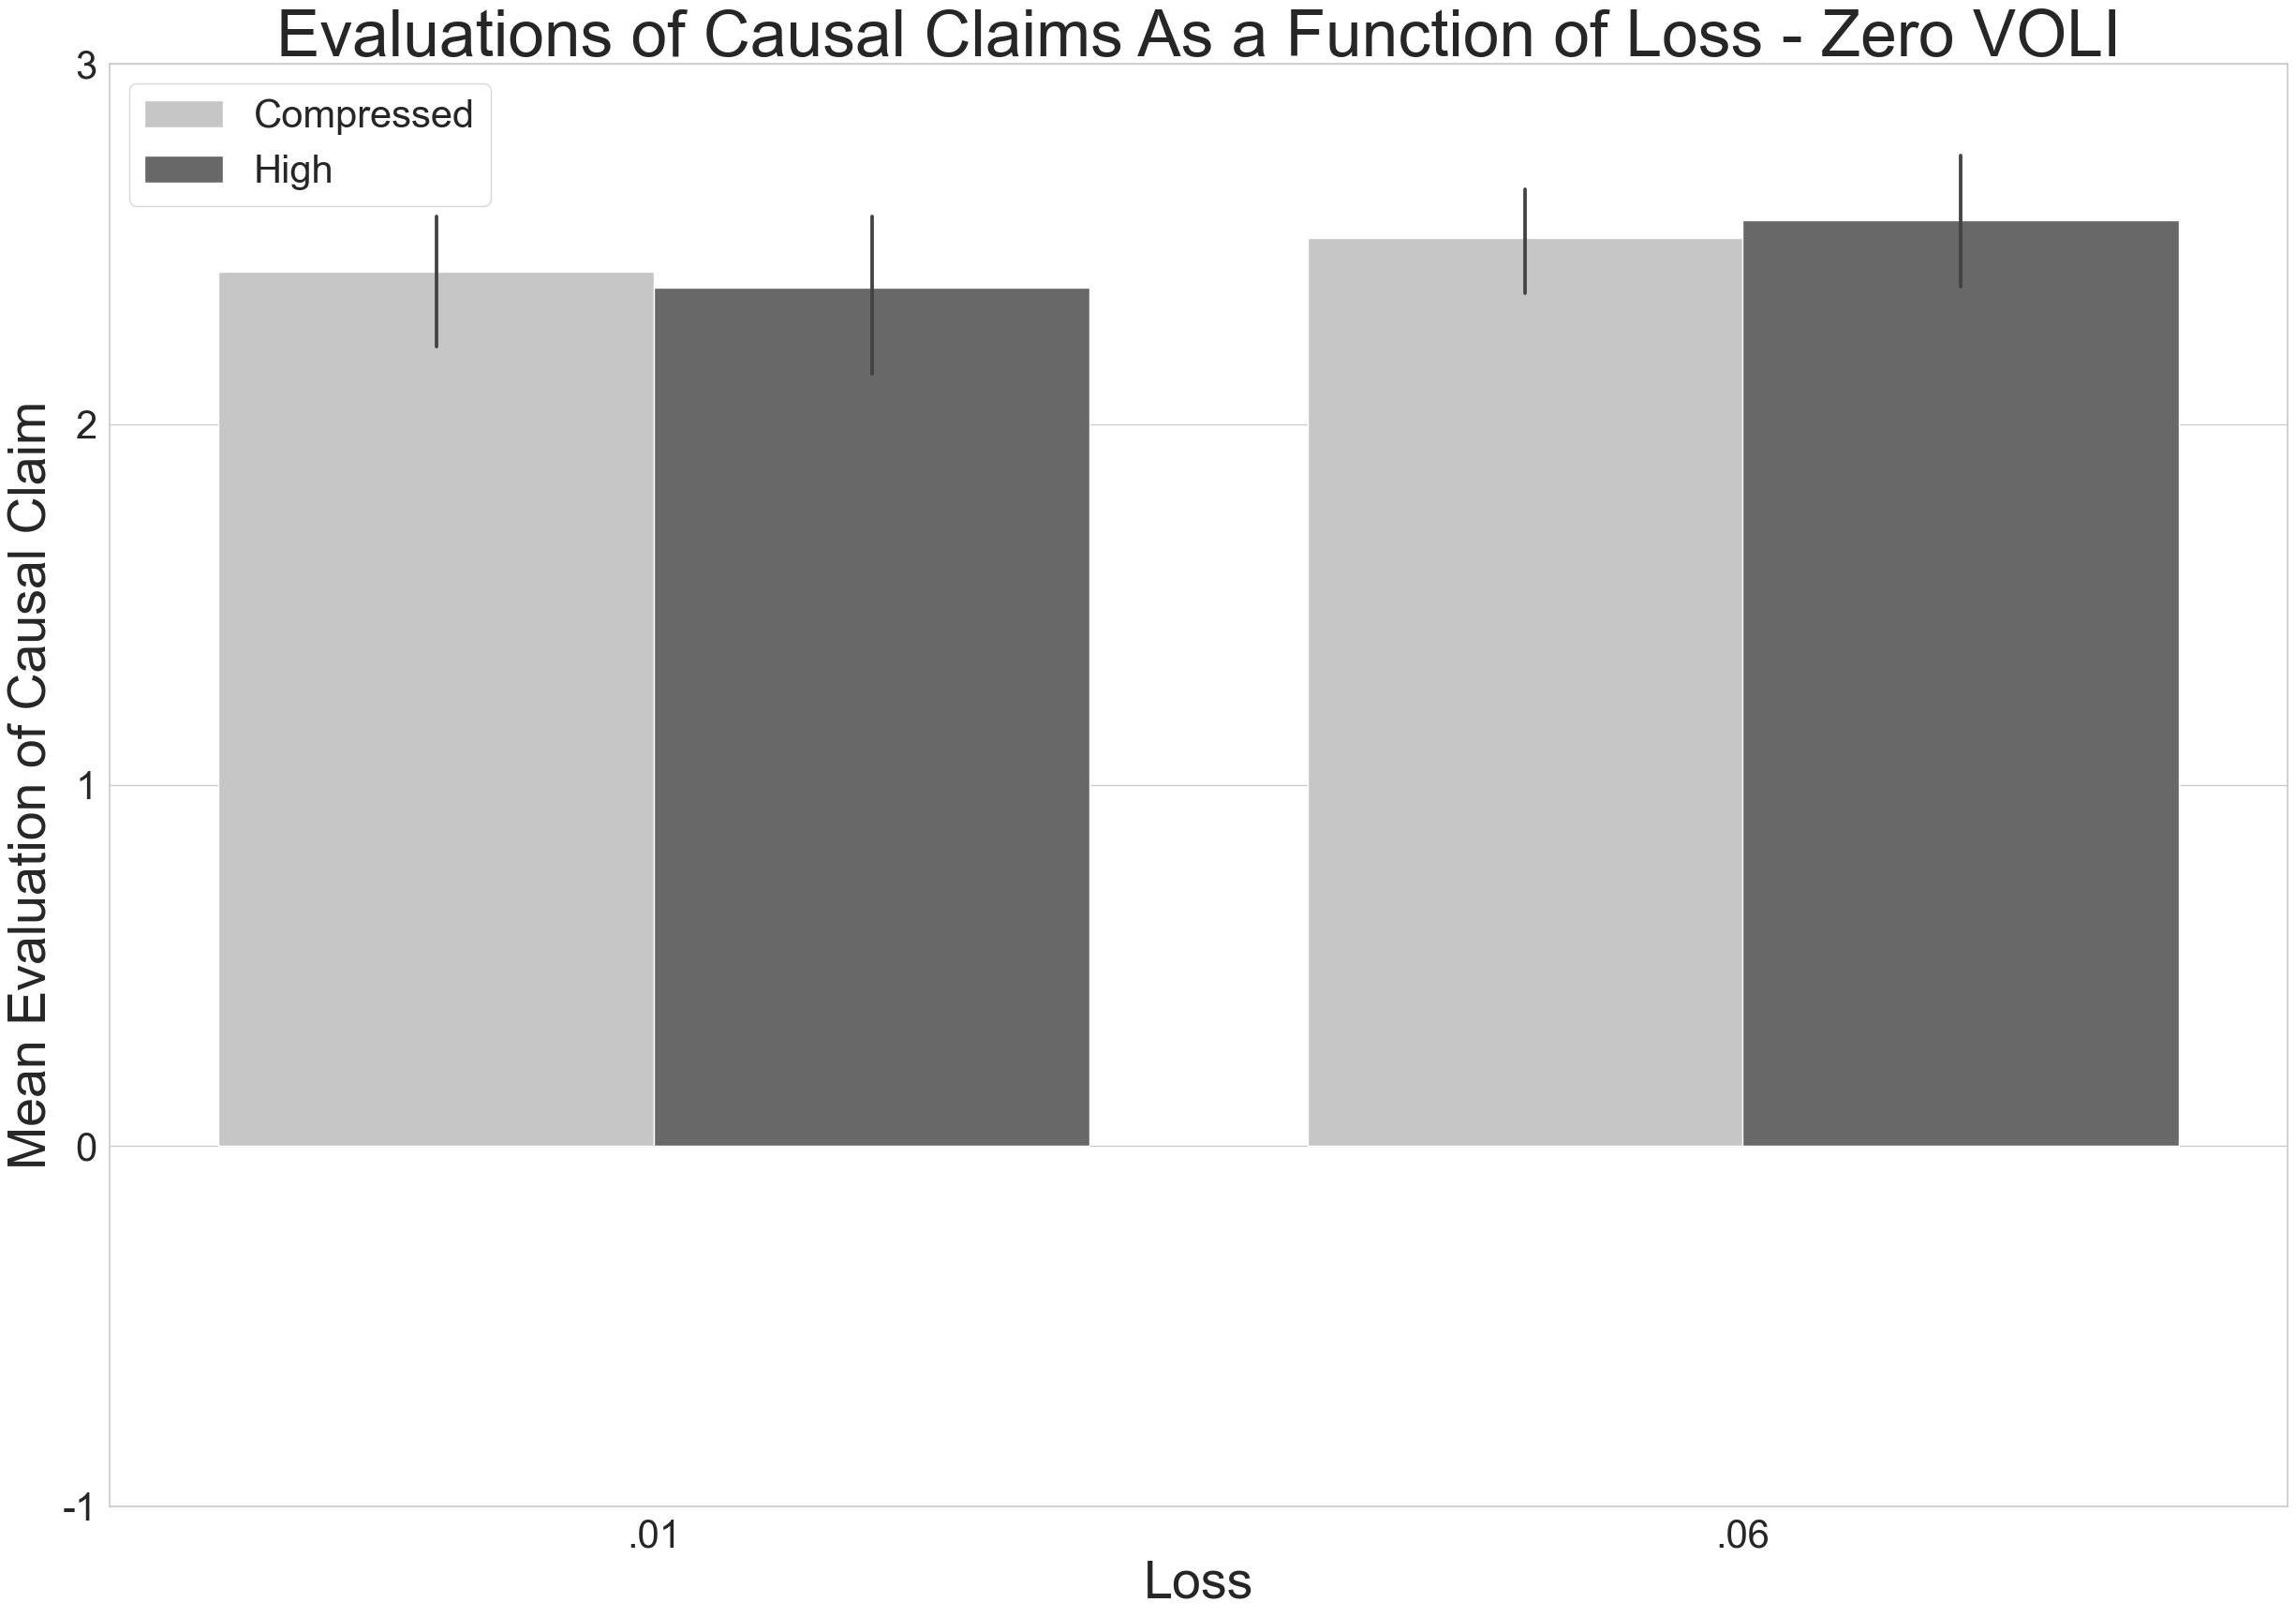

In [11]:
loss_vals = []
condition = []
diff_matters = []
comp_eval = []
high_eval = []
low_eval = []

for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No':
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06])
            
        if data.Condition[i] == 'Prop':
            condition = np.append(condition,[-1])
        if data.Condition[i] == 'Stab':
            condition = np.append(condition,[1])
            
        if data.Vignette[i] == 'Training':
            comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
            
arr = np.hstack((condition.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Condition', 'Loss', 'Compressed', 'High'])
datamelt = df.melt('Loss', value_vars=['Compressed','High'],var_name='')
sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax=sns.barplot(x='Loss', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('Loss',fontsize=40)
ax.set_xticklabels(['.01','.06'],fontsize=30)
ax.set_yticklabels(['-1','0','1','2','3'],fontsize=30)
ax.set_title('Evaluations of Causal Claims As a Function of Loss - Zero VOLI',fontsize=50)
plt.legend(fontsize=30)
plt.yticks(ticks=[-1,0,1,2,3],fontsize=30)
plt.savefig('study4_zeroVOlI_barplot')

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_75350/1970089774.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['-1','0','1','2','3'],fontsize=30)


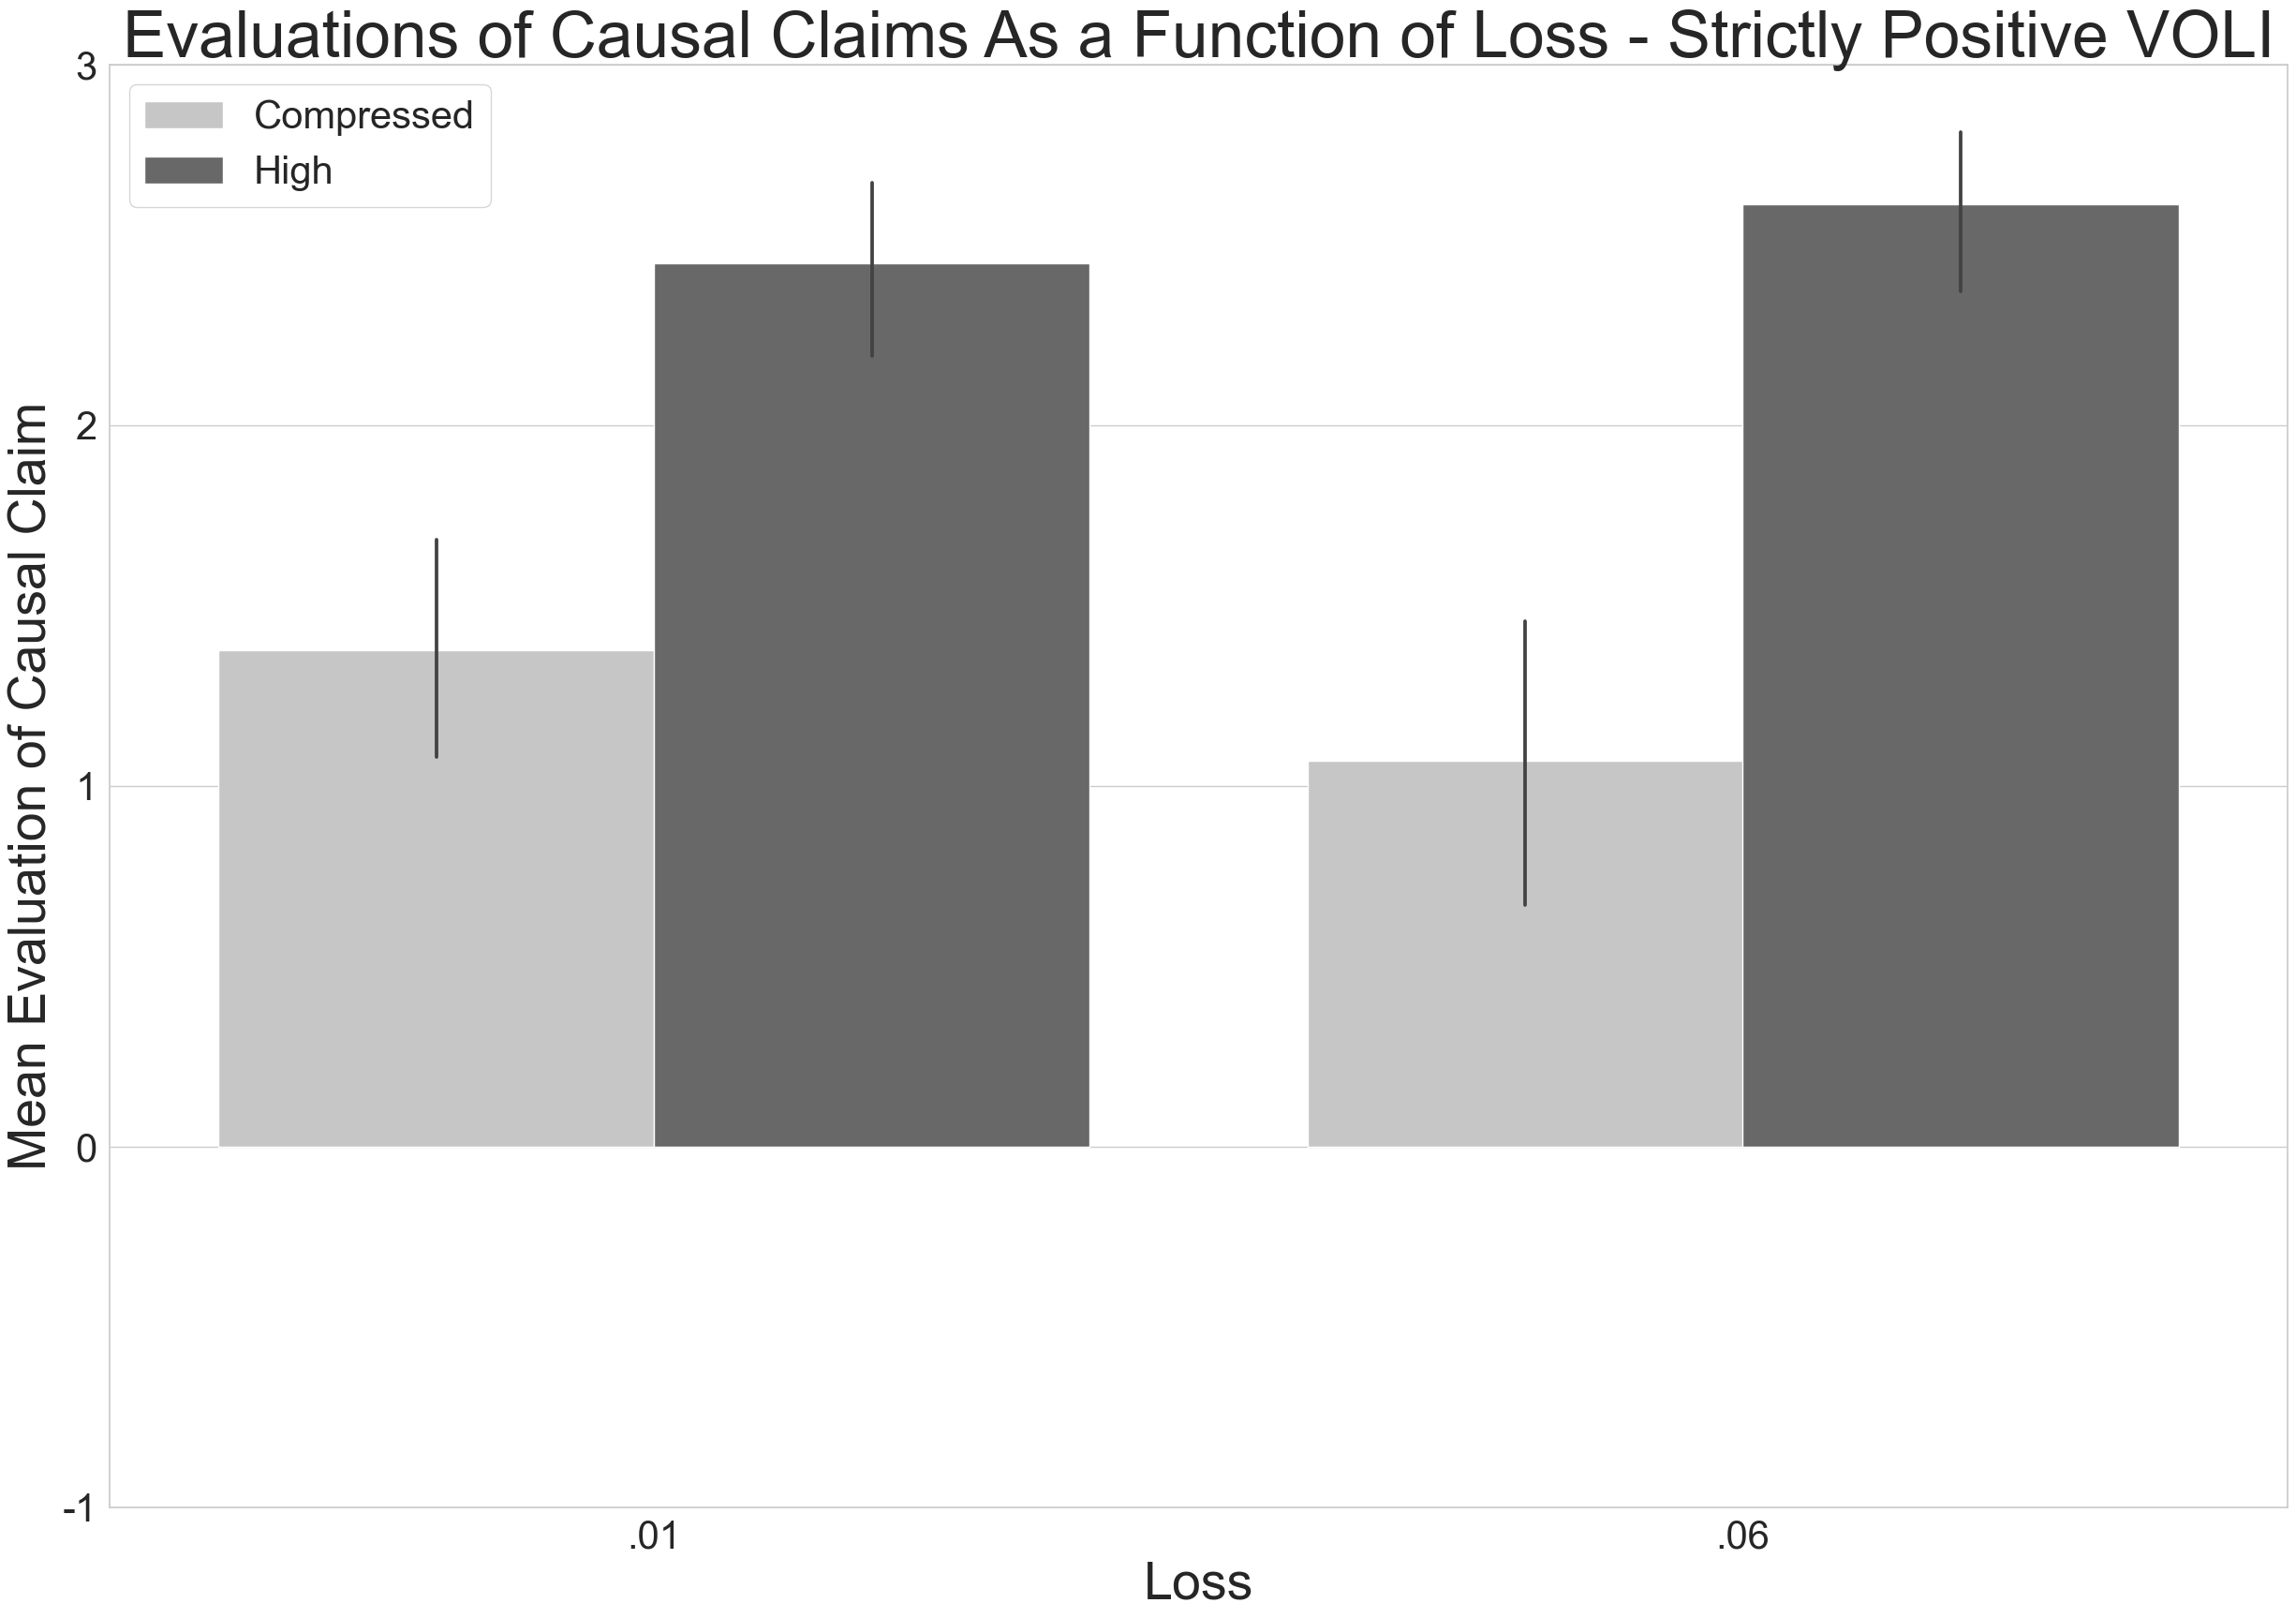

In [12]:
loss_vals = []
condition = []
diff_matters = []
comp_eval = []
high_eval = []
low_eval = []

for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes':
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06])
            
        if data.Condition[i] == 'Prop':
            condition = np.append(condition,[-1])
        if data.Condition[i] == 'Stab':
            condition = np.append(condition,[1])
            
        if data.Vignette[i] == 'Training':
            comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
            
arr = np.hstack((condition.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Condition', 'Loss', 'Compressed', 'High'])
datamelt = df.melt('Loss', value_vars=['Compressed','High'],var_name='')
sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax=sns.barplot(x='Loss', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('Loss',fontsize=40)
ax.set_ylim(-1,3)
ax.set_xticklabels(['.01','.06'],fontsize=30)
ax.set_yticklabels(['-1','0','1','2','3'],fontsize=30)
ax.set_title('Evaluations of Causal Claims As a Function of Loss - Strictly Positive VOLI',fontsize=50)
plt.legend(fontsize=30)
plt.yticks(ticks=[-1,0,1,2,3],fontsize=30)
plt.savefig('study4_posVOlI_barplot')

The following two blocks generate the figures comparing mean evaluations of causal claims in both the proportionality and stability settings of the mode of compression variable, as reported in the supplemental materials.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_80318/632812261.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['-1','0','1','2','3'],fontsize=30)


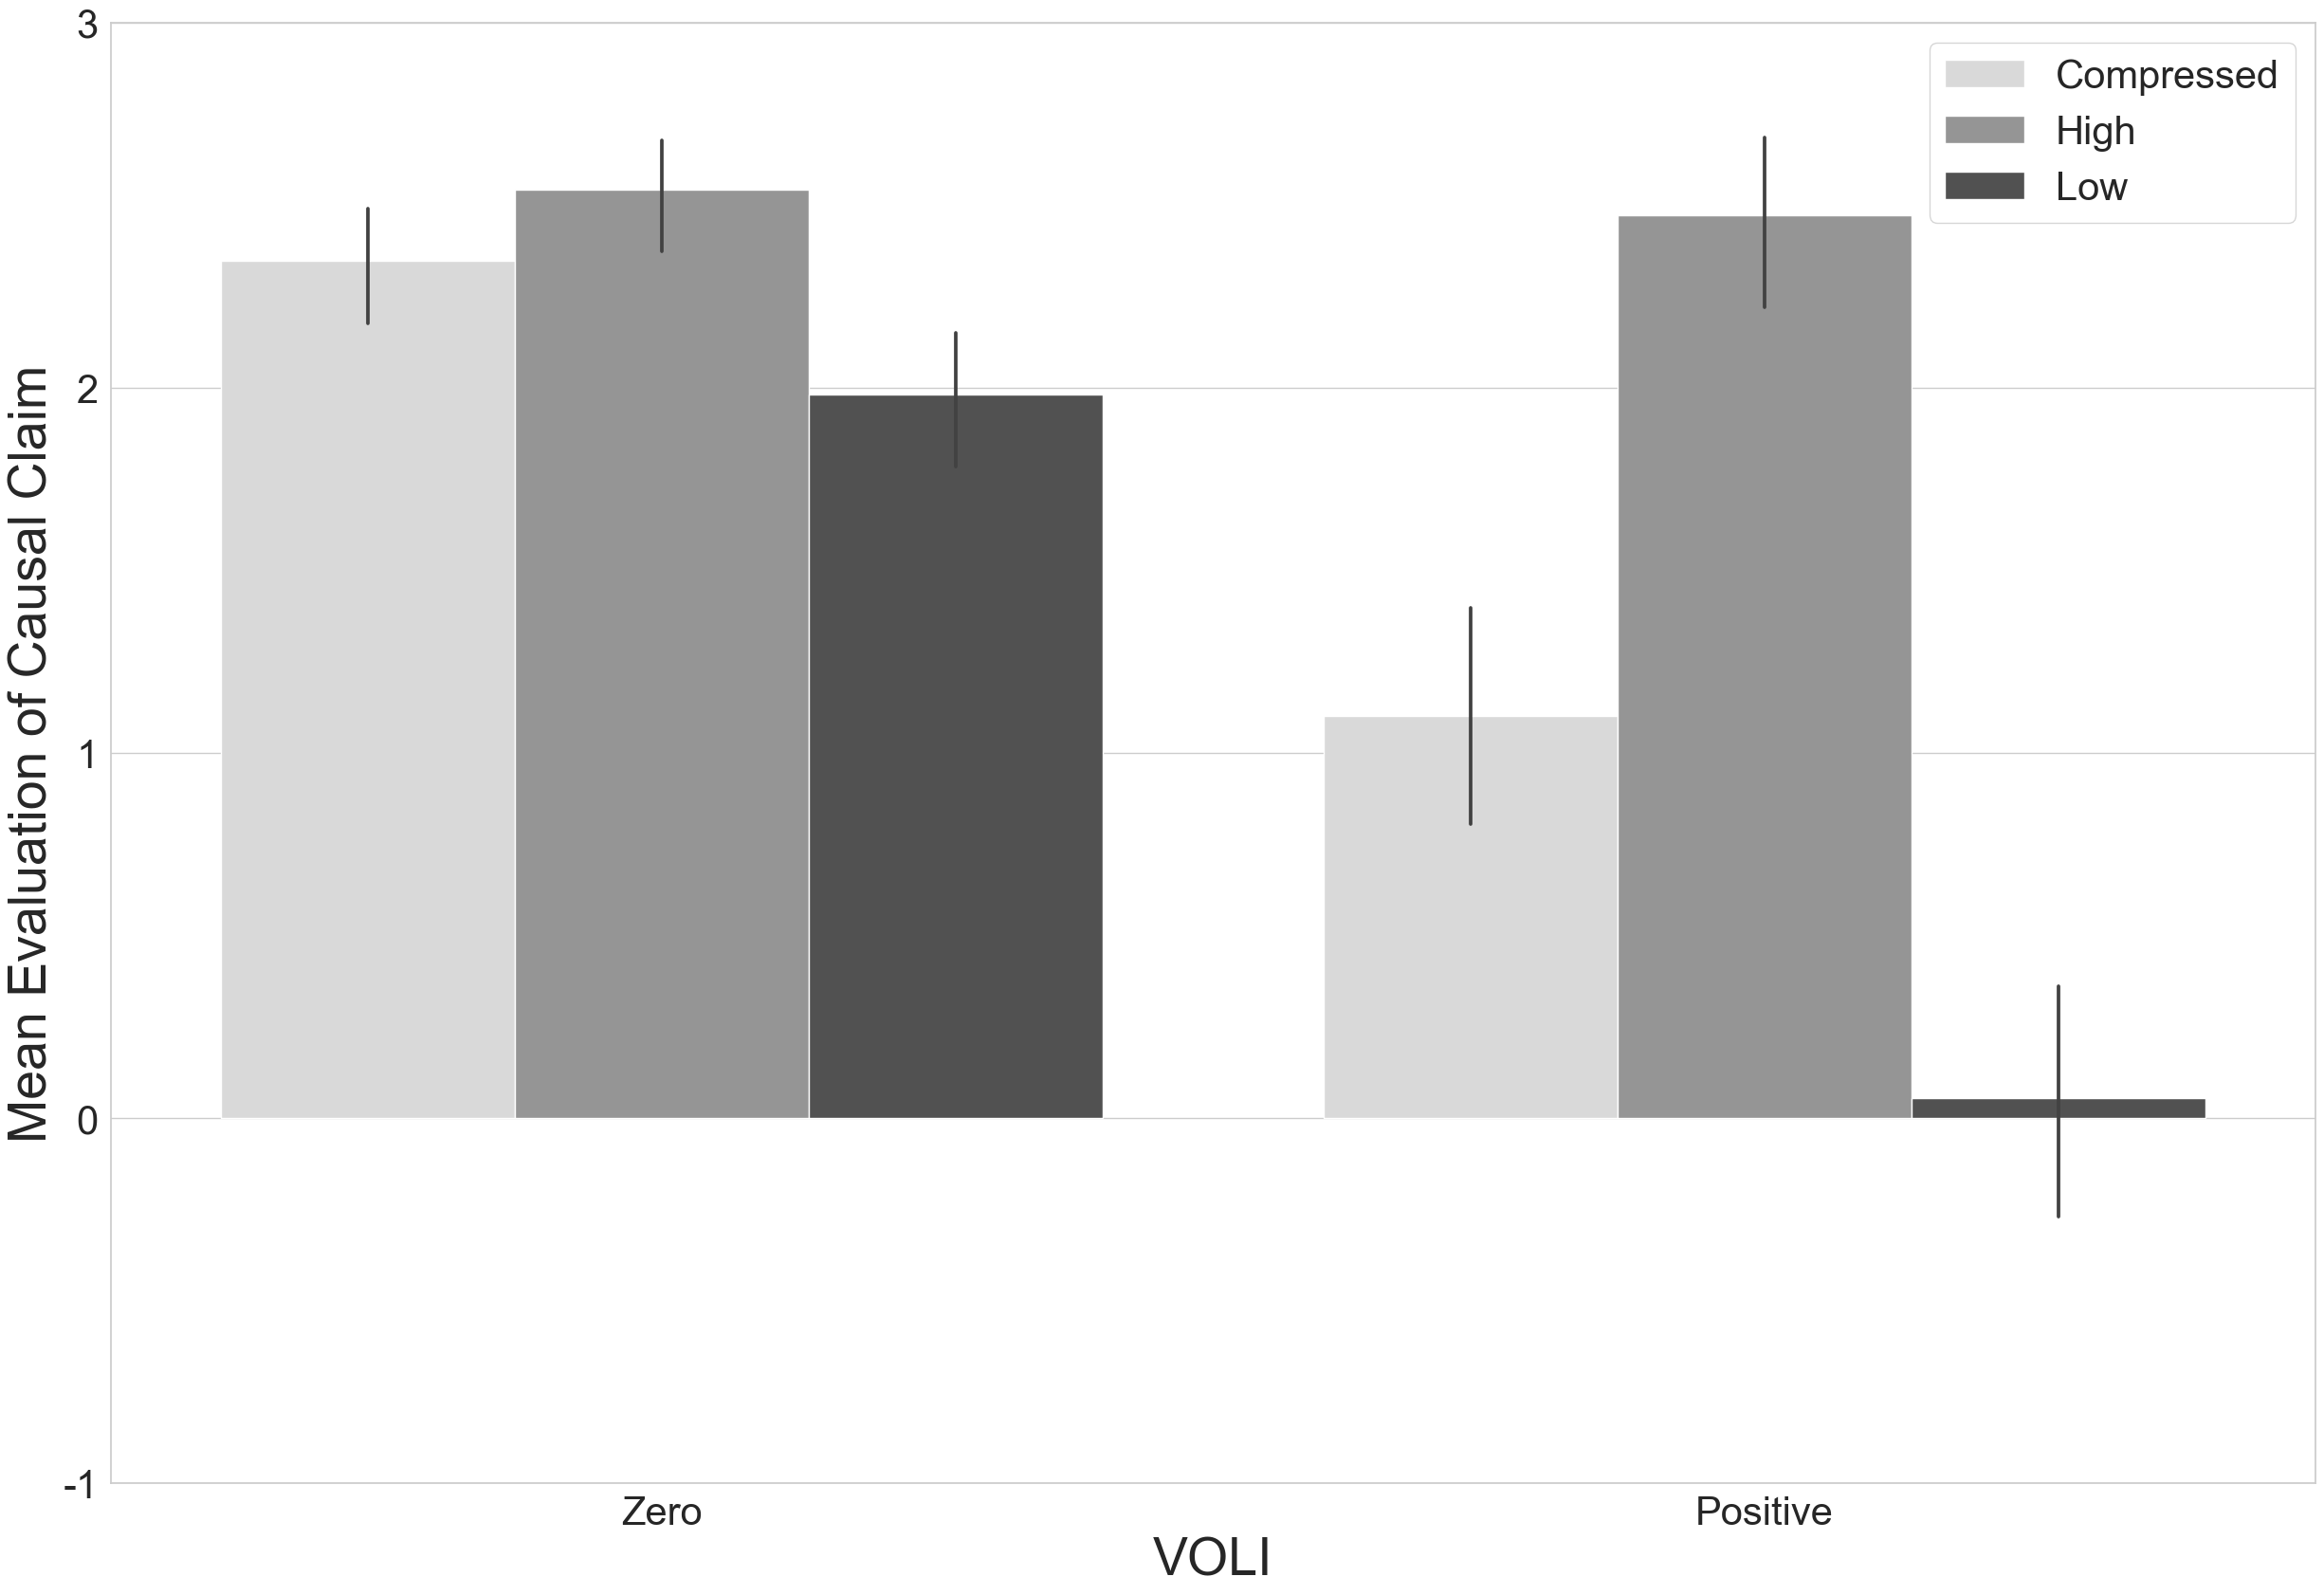

In [13]:
loss_vals = []
condition = []
diff_matters = []
comp_eval = []
high_eval = []
low_eval = []

for i in range(0,len(data)):
    if data.Condition[i] == 'Prop':
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06])
            
        if data.DifferenceMatters[i] == 'No':
            diff_matters = np.append(diff_matters,[-1])
        if data.DifferenceMatters[i] == 'Yes':
            diff_matters = np.append(diff_matters,[1])
            
        if data.Vignette[i] == 'Training':
            comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
            
arr = np.hstack((diff_matters.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1),low_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Loss', 'Compressed', 'High', 'Low'])
datamelt = df.melt('VOLI', value_vars=['Compressed','High','Low'],var_name='')
sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax=sns.barplot(x='VOLI', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('VOLI',fontsize=40)
ax.set_xticklabels(['Zero','Positive'],fontsize=30)
#ax.set_title('Evaluations of Causal Claims When Compression is \nAchieved by Coarsening a Causal Variable',fontsize=50)
ax.set_yticklabels(['-1','0','1','2','3'],fontsize=30)
#ax.set_title('Evaluations of Causal Claims As a Function of Loss - Strictly Positive VOLI',fontsize=50)
plt.legend(fontsize=30)
plt.yticks(ticks=[-1,0,1,2,3],fontsize=30)
plt.savefig('study4_prop_barplot')

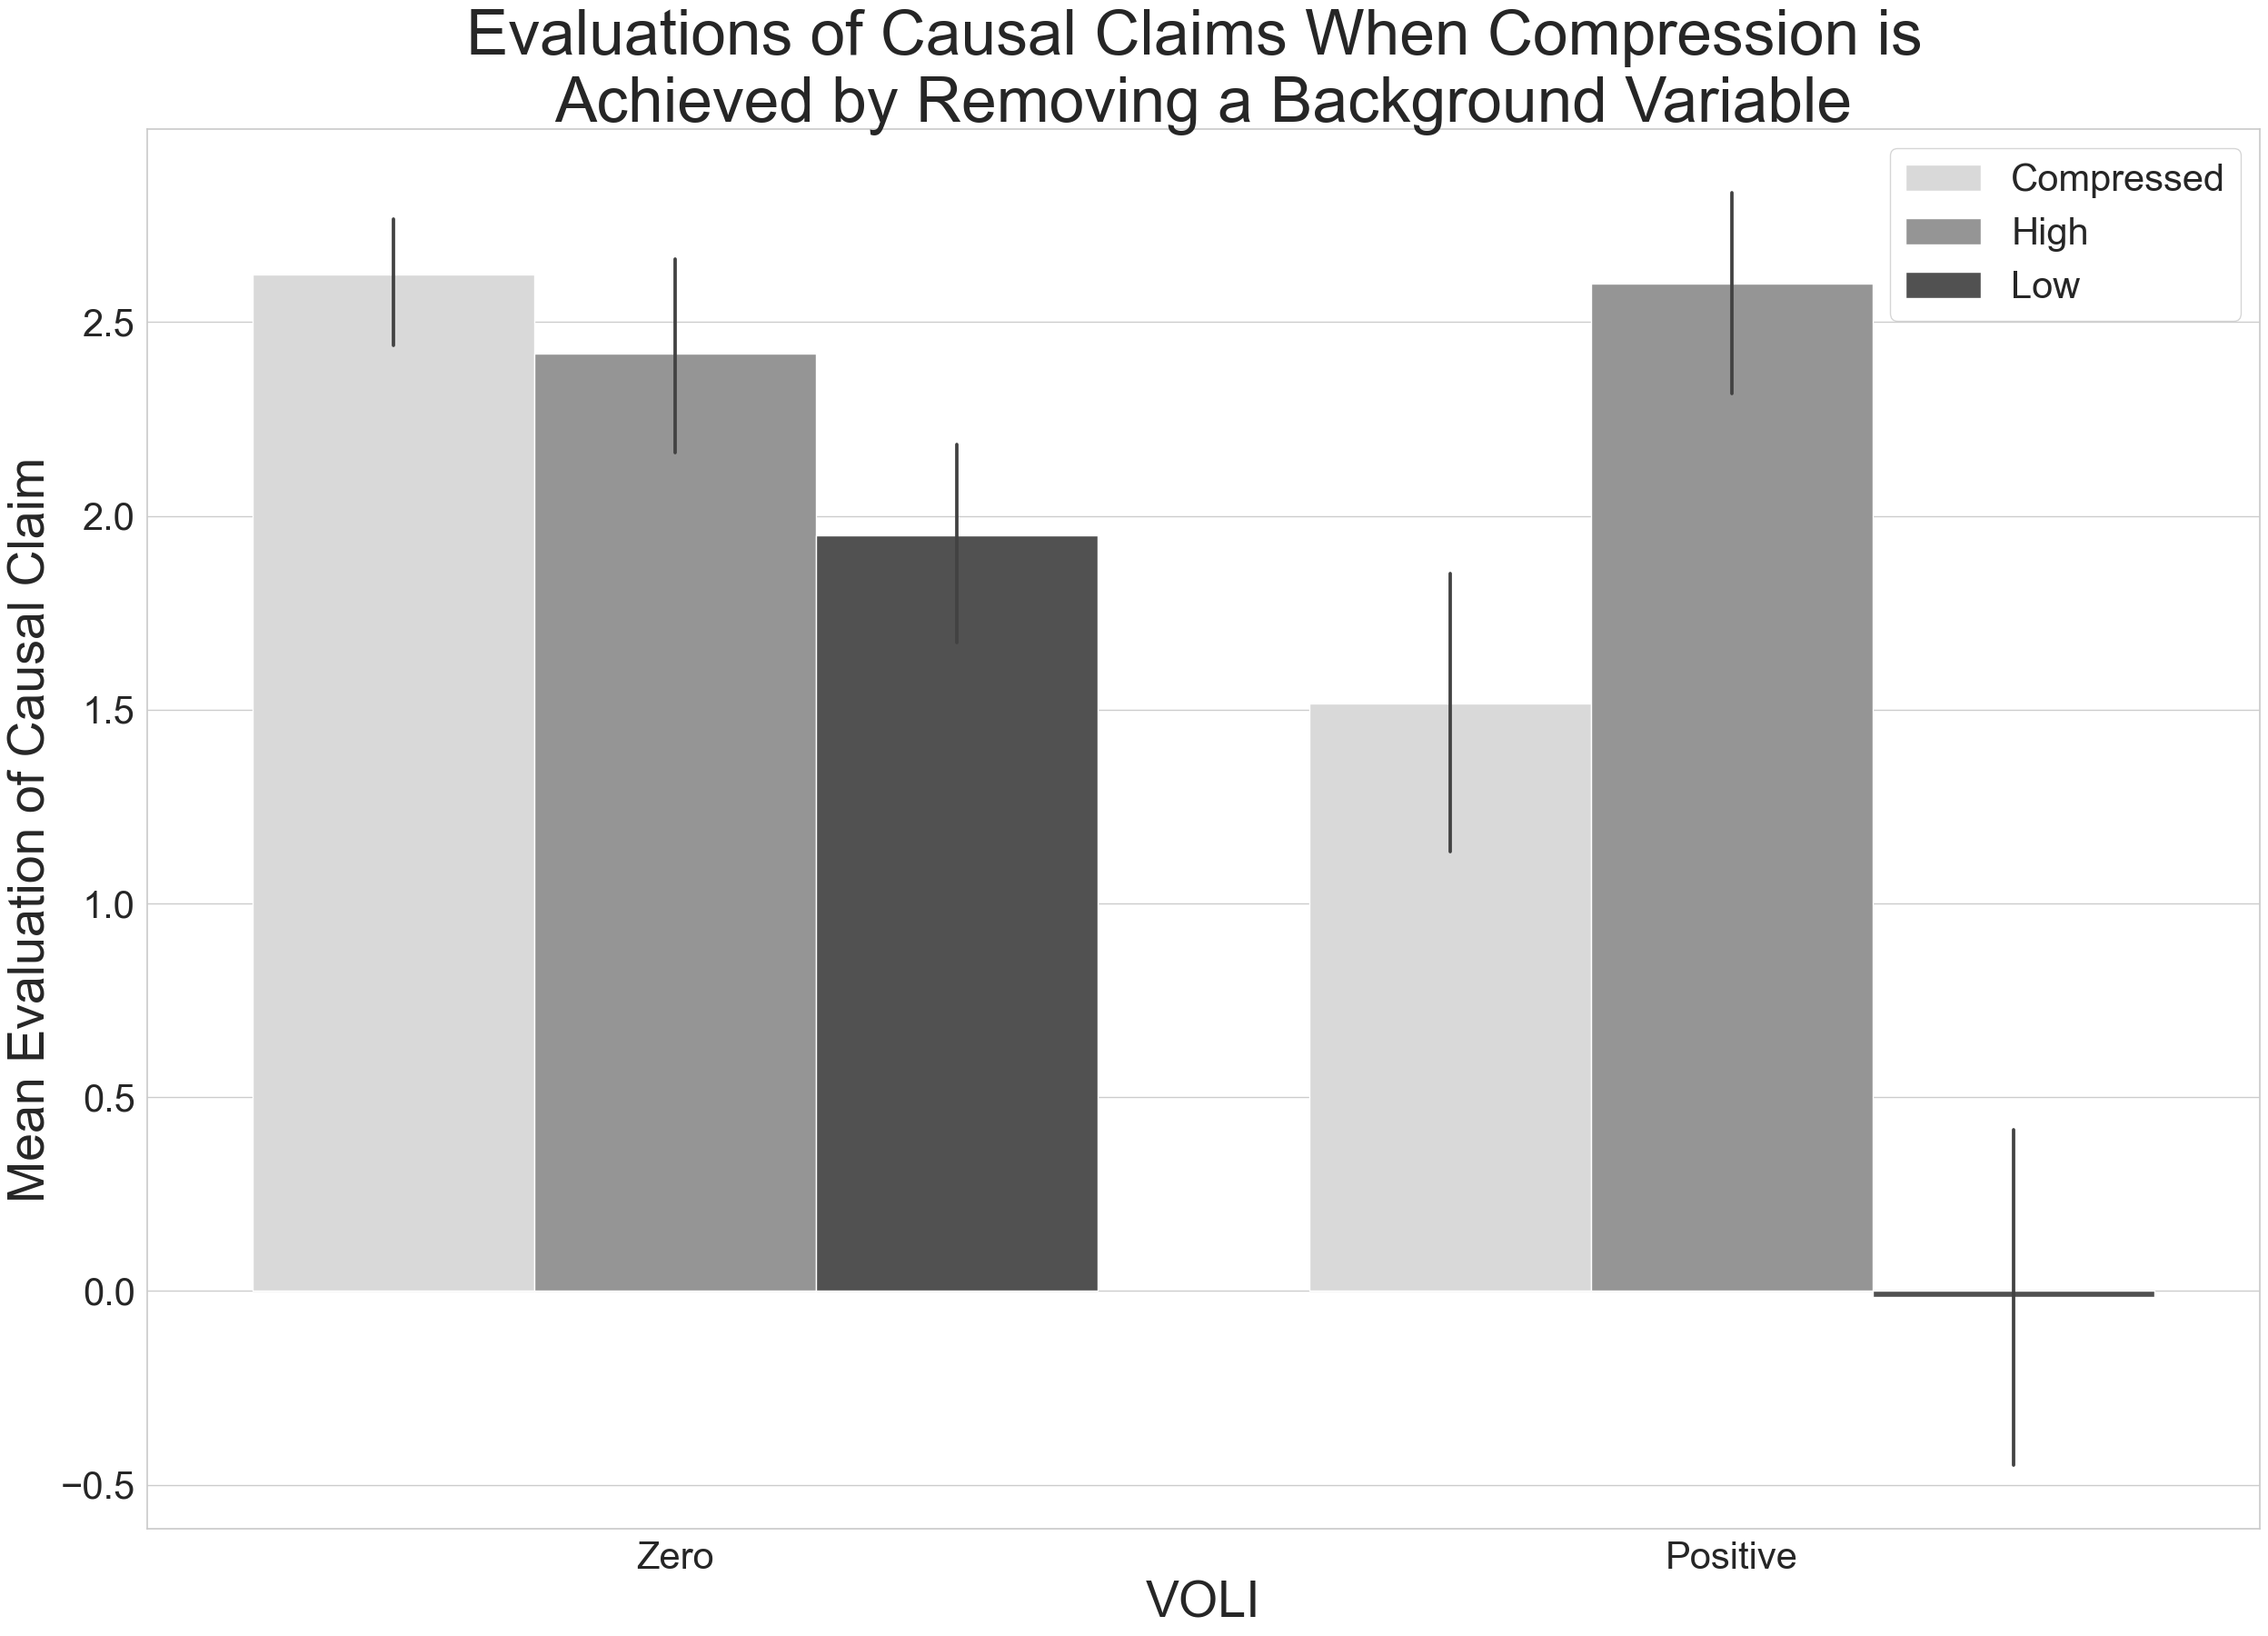

In [14]:
loss_vals = []
condition = []
diff_matters = []
comp_eval = []
high_eval = []
low_eval = []

for i in range(0,len(data)):
    if data.Condition[i] == 'Stab':
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06])
            
        if data.DifferenceMatters[i] == 'No':
            diff_matters = np.append(diff_matters,[-1])
        if data.DifferenceMatters[i] == 'Yes':
            diff_matters = np.append(diff_matters,[1])
            
        if data.Vignette[i] == 'Training':
            comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
            
arr = np.hstack((diff_matters.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1),low_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['VOLI', 'Loss', 'Compressed', 'High', 'Low'])
datamelt = df.melt('VOLI', value_vars=['Compressed','High','Low'],var_name='')
sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax=sns.barplot(x='VOLI', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('VOLI',fontsize=40)
ax.set_xticklabels(['Zero','Positive'],fontsize=30)
plt.yticks(fontsize=30)
ax.set_title('Evaluations of Causal Claims When Compression is \nAchieved by Removing a Background Variable',fontsize=50)
plt.legend(fontsize=30)
plt.savefig('study4_stab_barplot')

The following block regresses the difference COMPRESSED-High on Mode, Loss, and Vignette, and interaction effects between all combinations thereof, when data is restricted to the case where VOLI is strictly positive.

In [15]:
loss_vals = []
mode = []
diff_matters = []
comp_eval = []
high_eval = []
low_eval = []
vignette = []

for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes':
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1])
            
        if data.Vignette[i] == 'Training':
            comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            vignette = np.append(vignette,[-1])
        if data.Vignette[i] == 'Training':
            vignette = np.append(vignette,[1])
            
comp_high_diff = comp_eval - high_eval

arr = np.hstack((mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),comp_high_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Mode', 'Loss', 'Vignette', 'Comp_High_Diff'])
mod = smf.ols(formula='Comp_High_Diff ~  Mode + Loss + Vignette + Mode:Loss:Vignette +\
Mode:Loss + Mode:Vignette + Mode:Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:         Comp_High_Diff   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     1.985
Date:                Wed, 23 Aug 2023   Prob (F-statistic):             0.0708
Time:                        15:44:24   Log-Likelihood:                -297.09
No. Observations:                 168   AIC:                             608.2
Df Residuals:                     161   BIC:                             630.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.9167      0

In [16]:
loss_vals = []
mode = []
diff_matters = []
comp_eval = []
high_eval = []
low_eval = []
vignette = []

for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No':
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1])
            
        if data.Vignette[i] == 'Training':
            comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.T_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
            high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
            low_eval = np.append(low_eval,[int(data.P_CE_LowGood_1[i])])
            
        if data.Vignette[i] == 'Pharma':
            vignette = np.append(vignette,[-1])
        if data.Vignette[i] == 'Training':
            vignette = np.append(vignette,[1])
            
comp_high_diff = comp_eval - high_eval

arr = np.hstack((mode.reshape(-1,1),loss_vals.reshape(-1,1),vignette.reshape(-1,1),comp_high_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Mode', 'Loss', 'Vignette', 'Comp_High_Diff'])
mod = smf.ols(formula='Comp_High_Diff ~  Mode + Loss + Vignette + Mode:Loss:Vignette +\
Mode:Loss + Mode:Vignette + Mode:Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:         Comp_High_Diff   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.667
Date:                Wed, 23 Aug 2023   Prob (F-statistic):              0.131
Time:                        15:45:14   Log-Likelihood:                -329.67
No. Observations:                 210   AIC:                             673.3
Df Residuals:                     203   BIC:                             696.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0683      0

The following block calculates the percentage of participants who strictly prefer Compressed to High under each VOLI condition.

In [17]:
comp_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
    if data.Vignette[i] == 'Training':
        comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
    
high_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
    if data.Vignette[i] == 'Training':
        high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])

count1 = 0
count2 = 0
count3 = 0
count4 = 0
for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and comp_eval[i]>high_eval[i]:
        count1 = count1 + 1
    if data.DifferenceMatters[i] == 'No' and comp_eval[i]<=high_eval[i]:
        count2 = count2 + 1
    if data.DifferenceMatters[i] == 'Yes' and comp_eval[i]>high_eval[i]:
        count3 = count3 + 1
    if data.DifferenceMatters[i] == 'Yes' and comp_eval[i]<=high_eval[i]:
        count4 = count4 + 1
        
[count1/(count1+count2),count3/(count3+count4)]

[0.10952380952380952, 0.03571428571428571]

The following block calculates the percentage of participants who weakly prefer Compressed to High under each VOLI condition.

In [18]:
comp_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        comp_eval = np.append(comp_eval,[int(data.P_CE_CompGood_1[i])])
    if data.Vignette[i] == 'Training':
        comp_eval = np.append(comp_eval,[int(data.T_CE_CompGood_1[i])])
    
high_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Pharma':
        high_eval = np.append(high_eval,[int(data.P_CE_HighGood_1[i])])
    if data.Vignette[i] == 'Training':
        high_eval = np.append(high_eval,[int(data.T_CE_HighGood_1[i])])
    
count1 = 0
count2 = 0
count3 = 0
count4 = 0
for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and comp_eval[i]>=high_eval[i]:
        count1 = count1 + 1
    if data.DifferenceMatters[i] == 'No' and comp_eval[i]<high_eval[i]:
        count2 = count2 + 1
    if data.DifferenceMatters[i] == 'Yes' and comp_eval[i]>=high_eval[i]:
        count3 = count3 + 1
    if data.DifferenceMatters[i] == 'Yes' and comp_eval[i]<high_eval[i]:
        count4 = count4 + 1
        
[count1/(count1+count2),count3/(count3+count4)]

[0.7904761904761904, 0.25595238095238093]

The following block performs mixed ANOVA analysis of the difference between Compressed and High when VOLI is zero.

In [20]:
loss_vals = []
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01,.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06,.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_HighGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_HighGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),loss_vals.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette','Loss', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode","Loss"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode * Loss + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode, Loss

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode, Loss



Anova Table (Type 3 tests)

Response: Eval
                         Effect     df  MSE      F   ges p.value
1                      Vignette 1, 202 1.13   0.06 <.001    .805
2                          Mode 1, 202 1.13   1.22  .004    .270
3                          Loss 1, 202 1.13   1.19  .004    .276
4                 Vignette:Mode 1, 202 1.13 2.94 +  .009    .088
5                 Vignette:Loss 1, 202 1.13   0.14 <.001    .705
6                     Mode:Loss 1, 202 1.13   1.02  .003    .315
7            Vignette:Mode:Loss 1, 202 1.13   0.11 <.001    .744
8                     Eval_Type 1, 202 0.69   0.04 <.001    .847
9            Vignette:Eval_Type 1, 202 0.69 3.28 +  .006    .072
10               Mode:Eval_Type 1, 202 0.69 5.78 *  .011    .017
11               Loss:Eval_Type 1, 202 0.69   0.10 <.001    .750
12      Vignette:Mode:Eval_Type 1, 202 0.69   0.06 <.001    .814
13      Vignette:Loss:Eval_Type 1, 202 0.69 3.63 +  .007    .058
14          Mode:Loss:Eval_Type 1, 202 0.69   0

The following block performs mixed ANOVA analysis of the difference between Compressed and Low when VOLI is zero.

In [21]:
loss_vals = []
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01,.01])
        if data.Loss[i] == '2':
            loss_vals = np.append(loss_vals,[.06,.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),loss_vals.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette','Loss', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode","Loss"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode * Loss + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode, Loss

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode, Loss



Anova Table (Type 3 tests)

Response: Eval
                         Effect     df  MSE         F   ges p.value
1                      Vignette 1, 202 1.30      0.93  .003    .336
2                          Mode 1, 202 1.30      1.37  .004    .243
3                          Loss 1, 202 1.30      1.03  .003    .311
4                 Vignette:Mode 1, 202 1.30      0.47  .002    .495
5                 Vignette:Loss 1, 202 1.30      0.72  .002    .396
6                     Mode:Loss 1, 202 1.30      0.21 <.001    .650
7            Vignette:Mode:Loss 1, 202 1.30      1.01  .003    .316
8                     Eval_Type 1, 202 0.69 37.51 ***  .061   <.001
9            Vignette:Eval_Type 1, 202 0.69      0.03 <.001    .865
10               Mode:Eval_Type 1, 202 0.69    4.88 *  .008    .028
11               Loss:Eval_Type 1, 202 0.69      0.10 <.001    .755
12      Vignette:Mode:Eval_Type 1, 202 0.69      1.05  .002    .308
13      Vignette:Loss:Eval_Type 1, 202 0.69      0.06 <.001    .802
14   

The following block performs mixed ANOVA analysis of the difference between High and Low when VOLI is zero.

In [22]:
loss_vals = []
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01,.01])
        if data.Loss[i] == '2':
            loss_vals = np.append(loss_vals,[.06,.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_HighGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_HighGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),loss_vals.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette','Loss', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode","Loss"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode * Loss + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode, Loss

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode, Loss



Anova Table (Type 3 tests)

Response: Eval
                         Effect     df  MSE         F   ges p.value
1                      Vignette 1, 202 1.69      0.10 <.001    .755
2                          Mode 1, 202 1.69      0.26 <.001    .609
3                          Loss 1, 202 1.69      1.20  .004    .275
4                 Vignette:Mode 1, 202 1.69      0.56  .002    .454
5                 Vignette:Loss 1, 202 1.69      0.22 <.001    .638
6                     Mode:Loss 1, 202 1.69      0.12 <.001    .724
7            Vignette:Mode:Loss 1, 202 1.69      0.21 <.001    .644
8                     Eval_Type 1, 202 0.70 39.77 ***  .054   <.001
9            Vignette:Eval_Type 1, 202 0.70      2.66  .004    .104
10               Mode:Eval_Type 1, 202 0.70      0.04 <.001    .851
11               Loss:Eval_Type 1, 202 0.70      0.00 <.001    .996
12      Vignette:Mode:Eval_Type 1, 202 0.70      1.58  .002    .211
13      Vignette:Loss:Eval_Type 1, 202 0.70      2.71  .004    .101
14   

The following block performs mixed ANOVA analysis of the difference between Compressed and High when VOLI is strictly positive.

In [23]:
loss_vals = []
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01,.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06,.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_HighGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_HighGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),loss_vals.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette','Loss', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode","Loss"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode * Loss + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode, Loss

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode, Loss



Anova Table (Type 3 tests)

Response: Eval
                         Effect     df  MSE          F   ges p.value
1                      Vignette 1, 160 2.38    8.83 **  .037    .003
2                          Mode 1, 160 2.38     3.03 +  .013    .084
3                          Loss 1, 160 2.38       0.00 <.001    .964
4                 Vignette:Mode 1, 160 2.38       0.05 <.001    .830
5                 Vignette:Loss 1, 160 2.38     4.00 *  .017    .047
6                     Mode:Loss 1, 160 2.38       0.58  .003    .447
7            Vignette:Mode:Loss 1, 160 2.38       0.01 <.001    .923
8                     Eval_Type 1, 160 1.04 111.40 ***  .175   <.001
9            Vignette:Eval_Type 1, 160 1.04     4.00 *  .008    .047
10               Mode:Eval_Type 1, 160 1.04       2.48  .005    .117
11               Loss:Eval_Type 1, 160 1.04    7.92 **  .015    .005
12      Vignette:Mode:Eval_Type 1, 160 1.04       0.08 <.001    .779
13      Vignette:Loss:Eval_Type 1, 160 1.04       2.05  .004

The following block performs mixed ANOVA analysis of the difference between High and Low when VOLI is strictly positive.

In [24]:
loss_vals = []
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Loss[i] == '1':
            loss_vals = np.append(loss_vals,[.01,.01])
        if data.Loss[i] == '2':
                loss_vals = np.append(loss_vals,[.06,.06])
            
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_HighGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_HighGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),loss_vals.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette','Loss', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode","Loss"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode * Loss + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode, Loss

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode, Loss



Anova Table (Type 3 tests)

Response: Eval
                         Effect     df  MSE          F   ges p.value
1                      Vignette 1, 160 2.36  14.09 ***  .049   <.001
2                          Mode 1, 160 2.36       0.00 <.001    .981
3                          Loss 1, 160 2.36       0.10 <.001    .750
4                 Vignette:Mode 1, 160 2.36       2.47  .009    .118
5                 Vignette:Loss 1, 160 2.36     5.28 *  .019    .023
6                     Mode:Loss 1, 160 2.36       0.41  .002    .521
7            Vignette:Mode:Loss 1, 160 2.36       0.67  .002    .414
8                     Eval_Type 1, 160 1.67 271.66 ***  .414   <.001
9            Vignette:Eval_Type 1, 160 1.67     6.20 *  .016    .014
10               Mode:Eval_Type 1, 160 1.67       0.74  .002    .391
11               Loss:Eval_Type 1, 160 1.67     3.20 +  .008    .076
12      Vignette:Mode:Eval_Type 1, 160 1.67     5.48 *  .014    .020
13      Vignette:Loss:Eval_Type 1, 160 1.67       0.62  .002

The following block performs mixed ANOVA analysis of the difference between Compressed and Low when VOLI is zero and information loss is .01.

In [25]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and data.Loss[i] == '1':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect    df  MSE         F   ges p.value
1                Vignette 1, 88 1.19      1.62  .010    .207
2                    Mode 1, 88 1.19      1.29  .008    .258
3           Vignette:Mode 1, 88 1.19      1.40  .009    .240
4               Eval_Type 1, 88 0.93 14.00 ***  .065   <.001
5      Vignette:Eval_Type 1, 88 0.93      0.06 <.001    .807
6          Mode:Eval_Type 1, 88 0.93    2.93 +  .014    .090
7 Vignette:Mode:Eval_Type 1, 88 0.93      0.17 <.001    .677
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between Compressed and Low when VOLI is zero and information loss is .01.

In [26]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and data.Loss[i] == '1':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect    df  MSE         F   ges p.value
1                Vignette 1, 88 1.19      1.62  .010    .207
2                    Mode 1, 88 1.19      1.29  .008    .258
3           Vignette:Mode 1, 88 1.19      1.40  .009    .240
4               Eval_Type 1, 88 0.93 14.00 ***  .065   <.001
5      Vignette:Eval_Type 1, 88 0.93      0.06 <.001    .807
6          Mode:Eval_Type 1, 88 0.93    2.93 +  .014    .090
7 Vignette:Mode:Eval_Type 1, 88 0.93      0.17 <.001    .677
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between Compressed and Low when VOLI is zero and information loss is .06.

In [27]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and data.Loss[i] == '2':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect     df  MSE         F   ges p.value
1                Vignette 1, 114 1.38      0.01 <.001    .934
2                    Mode 1, 114 1.38      0.27  .002    .604
3           Vignette:Mode 1, 114 1.38      0.05 <.001    .815
4               Eval_Type 1, 114 0.51 25.57 ***  .057   <.001
5      Vignette:Eval_Type 1, 114 0.51      0.00 <.001    .944
6          Mode:Eval_Type 1, 114 0.51      1.64  .004    .203
7 Vignette:Mode:Eval_Type 1, 114 0.51      1.33  .003    .251
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between High and Low when VOLI is zero and information loss is .31.

In [28]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'No' and data.Loss[i] == '2':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_HighGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_HighGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect     df  MSE         F   ges p.value
1                Vignette 1, 114 1.61      0.01 <.001    .903
2                    Mode 1, 114 1.61      0.44  .003    .509
3           Vignette:Mode 1, 114 1.61      0.05 <.001    .826
4               Eval_Type 1, 114 0.66 23.39 ***  .057   <.001
5      Vignette:Eval_Type 1, 114 0.66      0.00 <.001    .992
6          Mode:Eval_Type 1, 114 0.66      0.43  .001    .514
7 Vignette:Mode:Eval_Type 1, 114 0.66    2.87 +  .007    .093
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between Compressed and Low when VOLI is strictly positive and information loss is .01.

In [29]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes' and data.Loss[i] == '1':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect    df  MSE         F  ges p.value
1                Vignette 1, 94 3.12 17.18 *** .112   <.001
2                    Mode 1, 94 3.12      1.27 .009    .262
3           Vignette:Mode 1, 94 3.12      1.09 .008    .299
4               Eval_Type 1, 94 1.38 49.14 *** .138   <.001
5      Vignette:Eval_Type 1, 94 1.38      1.05 .003    .309
6          Mode:Eval_Type 1, 94 1.38    3.37 + .011    .070
7 Vignette:Mode:Eval_Type 1, 94 1.38      0.71 .002    .401
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between High and Low when VOLI is strictly positive and information loss is .01.

In [30]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes' and data.Loss[i] == '1':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_HighGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_HighGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect    df  MSE          F  ges p.value
1                Vignette 1, 94 2.11  22.48 *** .118   <.001
2                    Mode 1, 94 2.11       0.24 .001    .628
3           Vignette:Mode 1, 94 2.11       0.35 .002    .557
4               Eval_Type 1, 94 1.67 118.55 *** .358   <.001
5      Vignette:Eval_Type 1, 94 1.67       1.59 .007    .210
6          Mode:Eval_Type 1, 94 1.67       0.45 .002    .504
7 Vignette:Mode:Eval_Type 1, 94 1.67       2.33 .011    .130
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between Compressed and High when VOLI is strictly positive and information loss is .06.

In [30]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes' and data.Loss[i] == '2':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_CompGood_1[i]),int(data.T_CE_HighGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_CompGood_1[i]),int(data.P_CE_HighGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect    df  MSE         F   ges p.value
1                Vignette 1, 66 2.38      0.43  .004    .512
2                    Mode 1, 66 2.38      0.44  .004    .509
3           Vignette:Mode 1, 66 2.38      0.04 <.001    .834
4               Eval_Type 1, 66 1.25 68.36 ***  .263   <.001
5      Vignette:Eval_Type 1, 66 1.25    4.50 *  .023    .038
6          Mode:Eval_Type 1, 66 1.25      0.80  .004    .374
7 Vignette:Mode:Eval_Type 1, 66 1.25      0.21  .001    .647
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs mixed ANOVA analysis of the difference between High and Low when VOLI is strictly positive and information loss is .06.

In [31]:
mode = []
diff_matters = []
evals = []
subject = []
eval_type = []
vignette = []


for i in range(0,len(data)):
    if data.DifferenceMatters[i] == 'Yes' and data.Loss[i] == '2':
        subject = np.append(subject,[i,i])
        
        eval_type = np.append(eval_type,[-1,1])
        
        if data.Condition[i] == 'Prop':
            mode = np.append(mode,[-1,-1])
        if data.Condition[i] == 'Stab':
            mode = np.append(mode,[1,1])
            
        if data.Vignette[i] == 'Training':
            evals = np.append(evals,[int(data.T_CE_HighGood_1[i]),int(data.T_CE_LowGood_1[i])])
            vignette = np.append(vignette,[-1,-1])
            
        if data.Vignette[i] == 'Pharma':
            evals = np.append(evals,[int(data.P_CE_HighGood_1[i]),int(data.P_CE_LowGood_1[i])])
            vignette = np.append(vignette,[1,1])
            
arr = np.hstack((subject.reshape(-1,1),eval_type.reshape(-1,1),mode.reshape(-1,1),vignette.reshape(-1,1),evals.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Eval_Type','Mode', 'Vignette', 'Eval'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette","Mode"],
    within="Eval_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Eval_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect    df  MSE          F  ges p.value
1                Vignette 1, 66 2.71       0.85 .008    .361
2                    Mode 1, 66 2.71       0.18 .002    .675
3           Vignette:Mode 1, 66 2.71       2.28 .021    .136
4               Eval_Type 1, 66 1.67 153.24 *** .470   <.001
5      Vignette:Eval_Type 1, 66 1.67     4.93 * .028    .030
6          Mode:Eval_Type 1, 66 1.67       0.30 .002    .583
7 Vignette:Mode:Eval_Type 1, 66 1.67     3.15 + .018    .080
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1

